In [2]:
import numpy as np    
import matplotlib.pyplot as plt
%matplotlib inline    
 
from RENDES_fizinfo import *

In [3]:
# Egy motoros bemutatón az egyik motor először szabályos, 
# 10 m sugarú köröket ír le 12 s periódusidővel, 
# majd megtartva a körmozgás periódusidejét, 
# az eredeti vonalhoz képest jobbra-balra eltér 1 m-nyivel 2,5 s-os periódusidővel.
# 
# Ezért mozgását az alábbi egyenletek írják le:
# 
# φ(t) = (2π / 12) * t
# R(t) = 10 + 1 * sin((2π / 2.5) * t)
# x(t) = R(t) * cos(φ(t))
# y(t) = R(t) * sin(φ(t))

In [4]:
def motor_r(t):
    phi=(2*np.pi/12)*t
    R=10+1*np.sin(2*np.pi/2.5*t)
    x=R*np.cos(phi)
    y=R*np.sin(phi)
    
    return np.array([x, y], np.float64)

In [5]:
# a) Ábrázolja a motor pályáját az első 100 másodpercben! (2 p)
motor=num_kinem(2)   # 2D kinematikai számítások
motor.set_time_range(0.0, 100.0, 0.01)

motor.set_r_fun(motor_r)
motor.full_kinem_calc()

#motor.plot_rcomp()

In [6]:
# b) Mennyi a motor legnagyobb és legkisebb sebessége? (2 p)

motor.vmax = motor.v_abs.max()
motor.vmin = motor.v_abs.min()

print(f'A motor legnagyobb sebessege: {motor.vmax:.2f} m/s')
print(f'A motor legkisebb sebessege: {motor.vmin:.2f} m/s')

A motor legnagyobb sebessege: 5.91 m/s
A motor legkisebb sebessege: 4.71 m/s


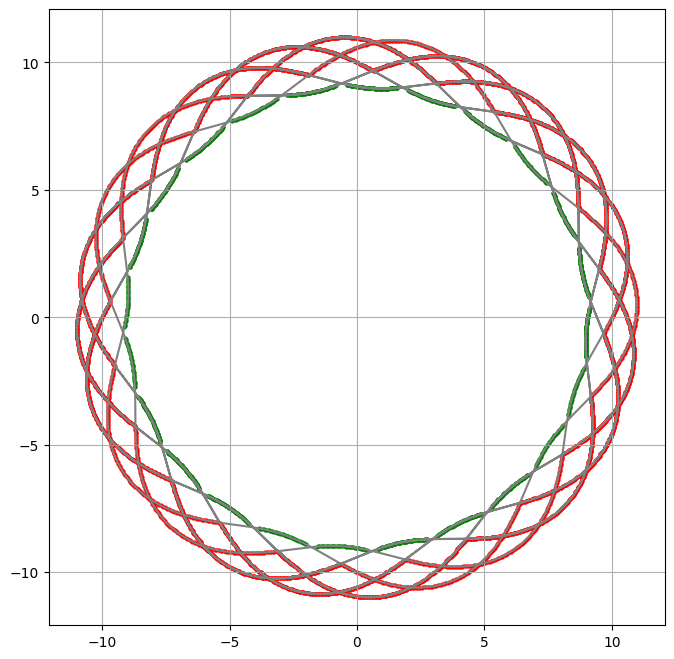

In [7]:
# c) Készítsen ábrát, melyen a motor pályája szürke, 
# és rajta pirossal be vannak jelölve azok a szakaszok, 
# ahol a sebesség nagyobb, mint a maximális sebesség 95%-a, 
# zölddel pedig azok, ahol a sebesség kisebb, mint a minimális sebesség 105%-a! (4 p)

gyors = motor.v_abs>0.95*motor.vmax 
lassu = motor.v_abs<1.05*motor.vmin

fig=plt.figure(figsize=(8,8))  
ax1=plt.subplot(111)

ax1.plot(motor.r[:,0], motor.r[:,1], color="grey")  # a pályagörbe
# a pályagörbe nagy a_cp-jű részeinél adatpontok:
ax1.scatter(motor.r[gyors,0], motor.r[gyors,1], color="red", s=4)  
ax1.scatter(motor.r[lassu,0], motor.r[lassu,1], color="green", s=4) 
ax1.set_aspect(aspect='equal')
ax1.grid()

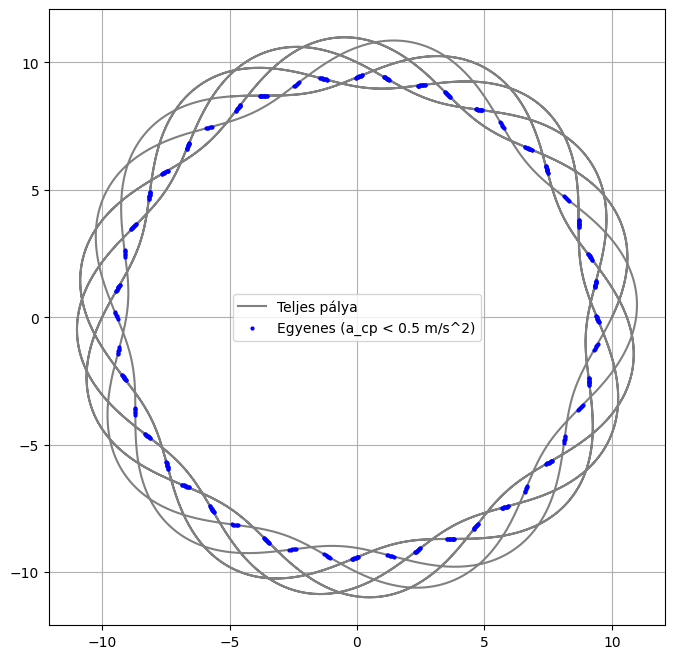

In [8]:
# d) Ábrázolja azokat a szakaszokat, ahol a motor közelítőleg egyenes vonalban haladt!

# Kiszámítjuk a gyorsulás-komponenseit (ha eddig nem tettük meg a kódban).
# Szükségünk van az 'a_cp_abs'-re, ami a kanyarodásért (irányváltoztatásért) felel.
motor.calc_at_acp_Rinv()

# Egyenes vonalú mozgásnál alig van irányváltoztatás, tehát a centripetális gyorsulás közel nulla.
# Készítünk egy maszkot, ami ott True, ahol az a_cp nagyon kicsi (< 0.5 m/s^2).
egyenes = motor.a_cp_abs < 0.5

fig = plt.figure(figsize=(8,8))  
ax1 = plt.subplot(111)

# A teljes pályagörbét kirajzoljuk szürkével
ax1.plot(motor.r[:,0], motor.r[:,1], color="grey", label="Teljes pálya")  

# A maszkot alkalmazva kékkel rajzoljuk a majdnem egyenes szakaszokat a vonal fölé (zorder=3)
ax1.scatter(motor.r[egyenes,0], motor.r[egyenes,1], 
            color="blue", s=4, zorder=3, label="Egyenes (a_cp < 0.5 m/s^2)")  

ax1.set_aspect(aspect='equal') # Torzításmentes megjelenítés (kör alakú marad a pálya)
ax1.legend()
ax1.grid()
plt.show()